# Loading the EuroSat dataset using PyTorch

In [2]:
import torch, torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
tf = transforms.Compose([
transforms.Resize(224), # ResNet's expected size
transforms.ToTensor(),
transforms.Normalize([0.485, 0.456, 0.406], # ImageNet normalization —
[0.229, 0.224, 0.225]), # required by pretrained weights
])
data = datasets.EuroSAT(root="data", download=True, transform=tf)
n = len(data)
train_ds, val_ds, test_ds = random_split(data, [int(n*0.7), int(n*0.15), n - int(n*0.7) - int(n*0.15)],
generator=torch.Generator().manual_seed(42))
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=64)
test_dl = DataLoader(test_ds, batch_size=64)

100%|██████████| 94.3M/94.3M [00:02<00:00, 46.3MB/s]


In [3]:
print(len(data))
print(data.classes)

27000
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


# Creating the baseline CNN

In [4]:
import torch.nn as nn

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
            nn.Flatten(), nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.net(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
base = SmallCNN().to(device)
opt_b = torch.optim.Adam(base.parameters(), lr=1e-3)
lossfn = nn.CrossEntropyLoss()

def evaluate_model(m, dl):
    m.eval(); correct = total = 0
    with torch.no_grad():
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            correct += (m(x).argmax(1) == y).sum().item()
            total += y.size(0)
    return correct / total

for epoch in range(3):
    base.train()
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        opt_b.zero_grad(); loss = lossfn(base(x), y); loss.backward(); opt_b.step()
    print(f"baseline epoch {epoch}: val acc = {evaluate_model(base, val_dl):.4f}")

baseline epoch 0: val acc = 0.5672
baseline epoch 1: val acc = 0.6198
baseline epoch 2: val acc = 0.6323


#Training and testing CNN on Euro Sat dataset

In [5]:
import torch.nn as nn

model = torchvision.models.resnet50(weights="IMAGENET1K_V2")
for p in model.parameters():
    p.requires_grad = False                      # freeze the vocabulary
model.fc = nn.Linear(model.fc.in_features, 10)   # new 10-class final layer

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

opt = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
lossfn = nn.CrossEntropyLoss()

def evaluate(dl):                                # accuracy on any split
    model.eval(); correct = total = 0
    with torch.no_grad():
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
            total += y.size(0)
    return correct / total

for epoch in range(3):                           # head-only training
    model.train()
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        opt.zero_grad(); loss = lossfn(model(x), y); loss.backward(); opt.step()
    print(f"epoch {epoch}: val accuracy = {evaluate(val_dl):.4f}")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 164MB/s]


epoch 0: val accuracy = 0.8956
epoch 1: val accuracy = 0.9138
epoch 2: val accuracy = 0.9274


# Visualizing model predictions

test accuracy: 0.9256790123456791
              precision    recall  f1-score   support

  AnnualCrop       0.88      0.96      0.92       472
      Forest       0.95      0.97      0.96       442
     HerbVeg       0.93      0.92      0.93       458
     Highway       0.89      0.82      0.85       391
  Industrial       0.93      0.95      0.94       378
     Pasture       0.89      0.93      0.91       299
    PermCrop       0.94      0.89      0.92       379
 Residential       0.95      0.98      0.97       450
       River       0.89      0.85      0.87       375
     SeaLake       0.98      0.96      0.97       406

    accuracy                           0.93      4050
   macro avg       0.92      0.92      0.92      4050
weighted avg       0.93      0.93      0.93      4050



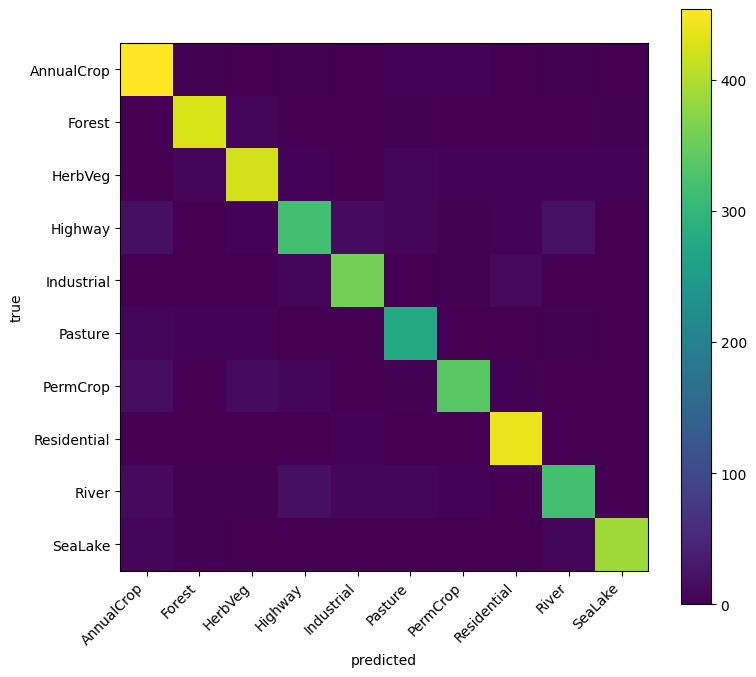

Mounted at /content/drive


In [7]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

classes = ["AnnualCrop","Forest","HerbVeg","Highway","Industrial",
           "Pasture","PermCrop","Residential","River","SeaLake"]

model.eval(); all_pred, all_true = [], []
with torch.no_grad():
    for x, y in test_dl:
        all_pred += model(x.to(device)).argmax(1).cpu().tolist()
        all_true += y.tolist()

print("test accuracy:", np.mean(np.array(all_pred) == np.array(all_true)))
print(classification_report(all_true, all_pred, target_names=classes))

cm = confusion_matrix(all_true, all_pred)
plt.figure(figsize=(8, 7)); plt.imshow(cm)
plt.xticks(range(10), classes, rotation=45, ha="right"); plt.yticks(range(10), classes)
plt.xlabel("predicted"); plt.ylabel("true"); plt.colorbar(); plt.tight_layout(); plt.show()

# then save to Drive so a disconnect costs nothing
from google.colab import drive
drive.mount("/content/drive")
torch.save(model.state_dict(), "/content/drive/MyDrive/eurosat_resnet50.pt")

# Restoring model

In [1]:
from google.colab import drive
import torch, torchvision
from torchvision import transforms, datasets
import numpy as np
import torch.nn as nn
drive.mount("/content/drive")
device = "cuda" if torch.cuda.is_available() else "cpu"
model = torchvision.models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)
model.load_state_dict(torch.load("/content/drive/MyDrive/eurosat_resnet50.pt", map_location=device))
model = model.to(device)
model.eval()
print("model restored")

Mounted at /content/drive
model restored


# Fetching images from google satalite

In [5]:
import ee
ee.Authenticate()
ee.Initialize(project="your_google_earth_project_id")

region = ee.Geometry.Rectangle([-63.30, -9.20, -63.20, -9.10])

def composite(year):
    col = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
           .filterBounds(region)
           .filterDate(f"{year}-06-01", f"{year}-08-31")
           .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20)))
    return col.median().select(["B4", "B3", "B2"]).clip(region)

for year in [2018, 2024]:
    task = ee.batch.Export.image.toDrive(
        image=composite(year).multiply(0.0001),
        description=f"amazon_{year}",
        folder="research2",
        scale=10,
        region=region,
        fileFormat="GeoTIFF",
        maxPixels=1e9)
    task.start()
    print("export started:", year)

export started: 2018
export started: 2024
2018 -> 12 images in composite
2024 -> 28 images in composite


# Resize the images to 17x17

In [10]:
import rasterio, numpy as np, torch
from PIL import Image
from google.colab import drive
from torchvision import transforms

tf = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])
drive.mount("/content/drive")

def load_geotiff(path):
    with rasterio.open(path) as src:
        img = src.read([1, 2, 3])                        # bands: R, G, B
    img = np.transpose(img, (1, 2, 0))                   # to height x width x 3
    img = np.clip(img / np.quantile(img, 0.98), 0, 1)    # brighten to 0-1
    return (img * 255).astype(np.uint8)

def classify_tiles(img, model, tile=64):
    h, w, _ = img.shape
    rows, cols = h // tile, w // tile
    labels = np.zeros((rows, cols), dtype=int)
    model.eval()
    with torch.no_grad():
        for r in range(rows):
            for c in range(cols):
                patch = img[r*tile:(r+1)*tile, c*tile:(c+1)*tile]
                x = tf(Image.fromarray(patch)).unsqueeze(0).to(device)
                labels[r, c] = model(x).argmax(1).item()
    return labels

img18 = load_geotiff("/content/drive/MyDrive/research2 (1)/amazon_2018.tif")
img24 = load_geotiff("/content/drive/MyDrive/research2 (1)/amazon_2024.tif")
map18 = classify_tiles(img18, model)
map24 = classify_tiles(img24, model)
print("grid shape:", map18.shape)

# SAVE THE MAPS IMMEDIATELY — the Cell-C ritual
import os
os.makedirs("/content/drive/MyDrive/research2", exist_ok=True)
np.save("/content/drive/MyDrive/research2 (1)/map18.npy", map18)
np.save("/content/drive/MyDrive/research2 (1)/map24.npy", map24)
print("maps saved to Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
grid shape: (17, 17)
maps saved to Drive


# Checking two amazon maps sensibility

Forest fraction 2018: 0.10726643598615918
Forest fraction 2024: 0.03806228373702422
2018 classes: (array([0, 1, 2, 3, 4, 5, 6, 8, 9]), array([136,  31,  34,  19,  22,   4,  14,  11,  18]))
2024 classes: (array([0, 1, 2, 3, 4, 5, 6, 8, 9]), array([198,  11,  25,  19,   5,   1,  11,   8,  11]))


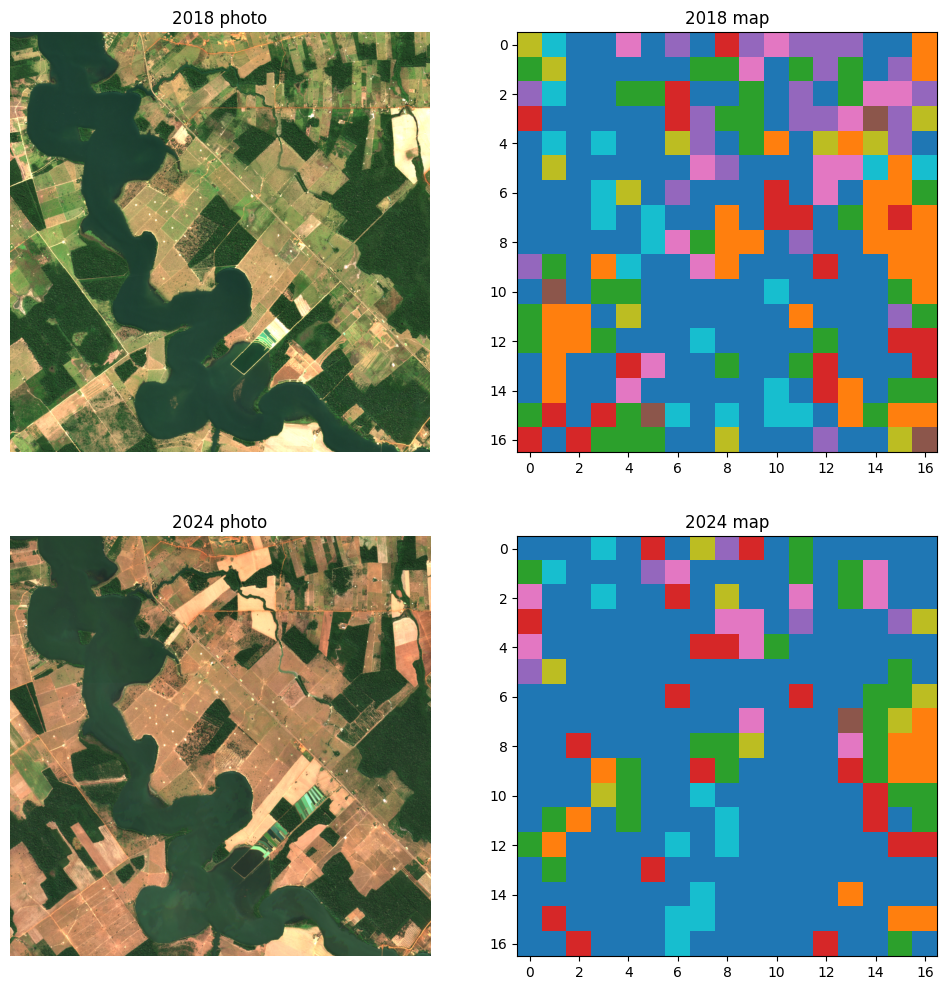

In [11]:
import matplotlib.pyplot as plt

# Forest fractions — THE sanity numbers
print("Forest fraction 2018:", (map18 == 1).mean())
print("Forest fraction 2024:", (map24 == 1).mean())

# what classes did it use at all?
print("2018 classes:", np.unique(map18, return_counts=True))
print("2024 classes:", np.unique(map24, return_counts=True))

# eyes on: photo vs map, both years
fig, ax = plt.subplots(2, 2, figsize=(12, 12))
ax[0,0].imshow(img18); ax[0,0].set_title("2018 photo"); ax[0,0].axis("off")
ax[0,1].imshow(map18, cmap="tab10", vmin=0, vmax=9); ax[0,1].set_title("2018 map")
ax[1,0].imshow(img24); ax[1,0].set_title("2024 photo"); ax[1,0].axis("off")
ax[1,1].imshow(map24, cmap="tab10", vmin=0, vmax=9); ax[1,1].set_title("2024 map")
plt.show()

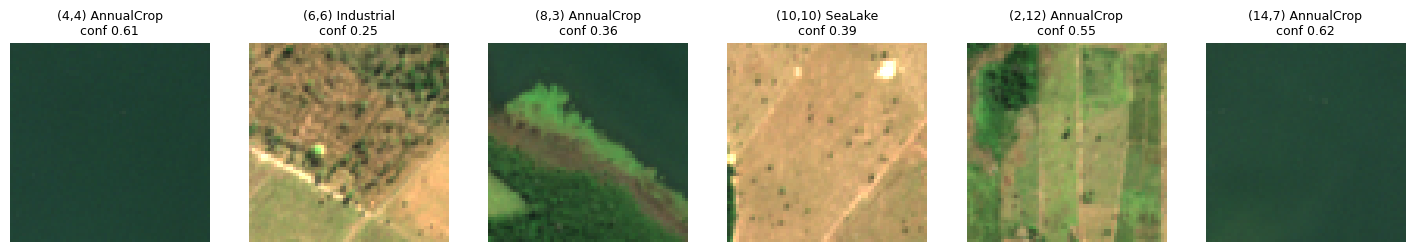

mean confidence on Amazon 2018: 0.5 (EuroSAT test was ~0.95+)


In [12]:
import torch.nn.functional as F

classes = ["AnnualCrop","Forest","HerbVeg","Highway","Industrial",
           "Pasture","PermCrop","Residential","River","SeaLake"]

# pick 6 patches: change (r,c) pairs to hit obvious water/forest spots you see in the photo
spots = [(4,4), (6,6), (8,3), (10,10), (2,12), (14,7)]
fig, ax = plt.subplots(1, 6, figsize=(18, 3.5))
for i, (r, c) in enumerate(spots):
    patch = img18[r*64:(r+1)*64, c*64:(c+1)*64]
    x = tf(Image.fromarray(patch)).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(x), 1)[0]
    top = probs.argmax().item()
    ax[i].imshow(patch); ax[i].axis("off")
    ax[i].set_title(f"({r},{c}) {classes[top]}\nconf {probs[top]:.2f}", fontsize=9)
plt.show()

# overall confidence — domain-gap thermometer
model.eval(); confs = []
with torch.no_grad():
    for r in range(17):
        for c in range(17):
            p = img18[r*64:(r+1)*64, c*64:(c+1)*64]
            x = tf(Image.fromarray(p)).unsqueeze(0).to(device)
            confs.append(F.softmax(model(x),1).max().item())
print("mean confidence on Amazon 2018:", np.mean(confs).round(3), "(EuroSAT test was ~0.95+)")

# Test if image brightness affects performance

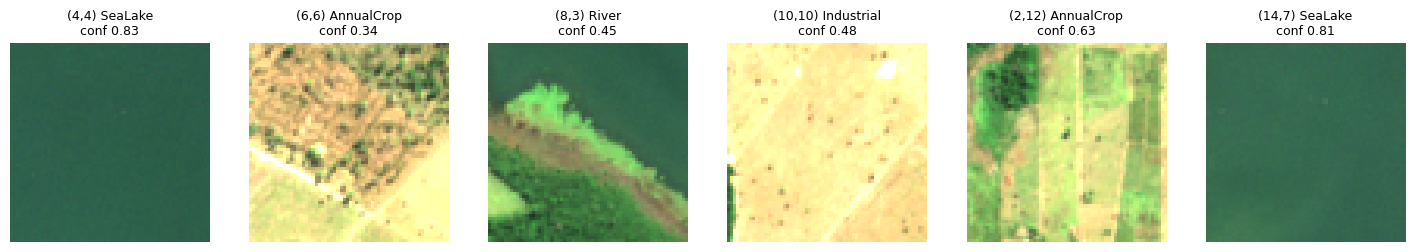

mean confidence, brighter prep: 0.524


In [13]:
def load_geotiff_v2(path, q=0.90):     # stronger brightening than v1's 0.98
    with rasterio.open(path) as src:
        img = src.read([1, 2, 3])
    img = np.transpose(img, (1, 2, 0))
    img = np.clip(img / np.quantile(img, q), 0, 1)
    return (img * 255).astype(np.uint8)

img18_b = load_geotiff_v2("/content/drive/MyDrive/research2 (1)/amazon_2018.tif")

fig, ax = plt.subplots(1, 6, figsize=(18, 3.5))
for i, (r, c) in enumerate(spots):
    patch = img18_b[r*64:(r+1)*64, c*64:(c+1)*64]
    x = tf(Image.fromarray(patch)).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(x), 1)[0]
    top = probs.argmax().item()
    ax[i].imshow(patch); ax[i].axis("off")
    ax[i].set_title(f"({r},{c}) {classes[top]}\nconf {probs[top]:.2f}", fontsize=9)
plt.show()

confs = []
with torch.no_grad():
    for r in range(17):
        for c in range(17):
            p = img18_b[r*64:(r+1)*64, c*64:(c+1)*64]
            x = tf(Image.fromarray(p)).unsqueeze(0).to(device)
            confs.append(F.softmax(model(x),1).max().item())
print("mean confidence, brighter prep:", np.mean(confs).round(3))

# Building the change map - flagging forests

In [18]:
gfc = ee.Image("UMD/hansen/global_forest_change_2025_v1_13")
lossyear = gfc.select("lossyear").clip(region)     # 0 = no loss, 19 = 2019 ... 24 = 2024

task = ee.batch.Export.image.toDrive(
    image=lossyear, description="hansen_lossyear", folder="research2",
    scale=30, region=region, fileFormat="GeoTIFF", maxPixels=1e9)
task.start()

print("hansen export started")

hansen export started


# Grading the model against hansen

flagged patches: 20
Hansen-loss patches: 63
TP=12  FP=8  FN=51  TN=218
precision=0.60   recall=0.19


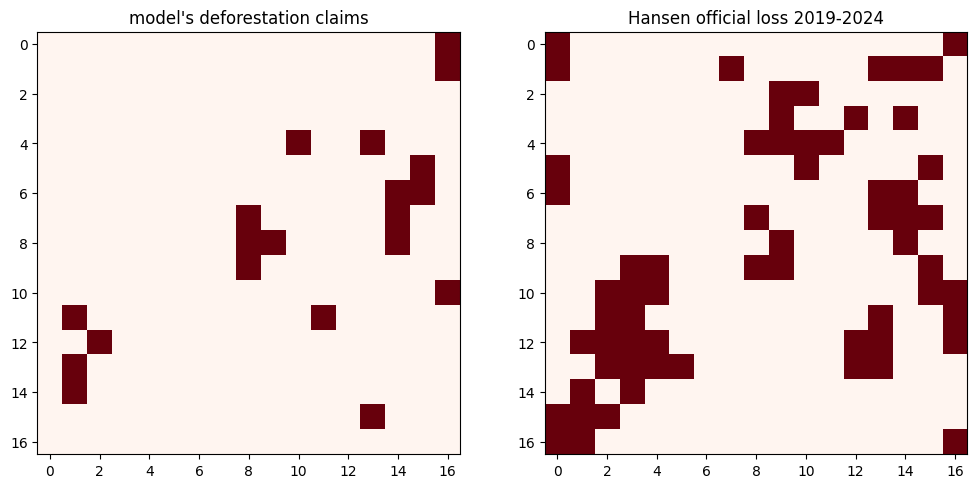

In [19]:
import numpy as np
map18 = np.load("/content/drive/MyDrive/research2 (1)/map18.npy")
map24 = np.load("/content/drive/MyDrive/research2 (1)/map24.npy")

FOREST = 1
change = (map18 == FOREST) & (map24 != FOREST)
print("flagged patches:", change.sum())
with rasterio.open("/content/drive/MyDrive/research2 (1)/hansen_lossyear.tif") as src:
    ly = src.read(1)

loss_in_window = (ly >= 19) & (ly <= 24)           # loss during 2019-2024
rows, cols = map18.shape
scale_r, scale_c = ly.shape[0] // rows, ly.shape[1] // cols
hansen = np.zeros((rows, cols), dtype=bool)
for r in range(rows):
    for c in range(cols):
        block = loss_in_window[r*scale_r:(r+1)*scale_r, c*scale_c:(c+1)*scale_c]
        hansen[r, c] = block.mean() > 0.10          # threshold: >10% of pixels lost

print("Hansen-loss patches:", hansen.sum())

# ===== THE FOUR BOXES — the whole project lands here =====
tp = (change & hansen).sum()       # you both saw it
fp = (change & ~hansen).sum()      # you cried wolf
fn = (~change & hansen).sum()      # you missed it
tn = (~change & ~hansen).sum()     # both saw nothing
precision = tp / (tp + fp) if (tp + fp) else float("nan")
recall = tp / (tp + fn) if (tp + fn) else float("nan")
print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"precision={precision:.2f}   recall={recall:.2f}")

# side-by-side: your claims vs Hansen's record
fig, ax = plt.subplots(1, 2, figsize=(12, 5.5))
ax[0].imshow(change, cmap="Reds"); ax[0].set_title("model's deforestation claims")
ax[1].imshow(hansen, cmap="Reds"); ax[1].set_title("Hansen official loss 2019-2024")
plt.show()

# Visualizing what the model missed and what it predicted incorrectly

missed patches: 51


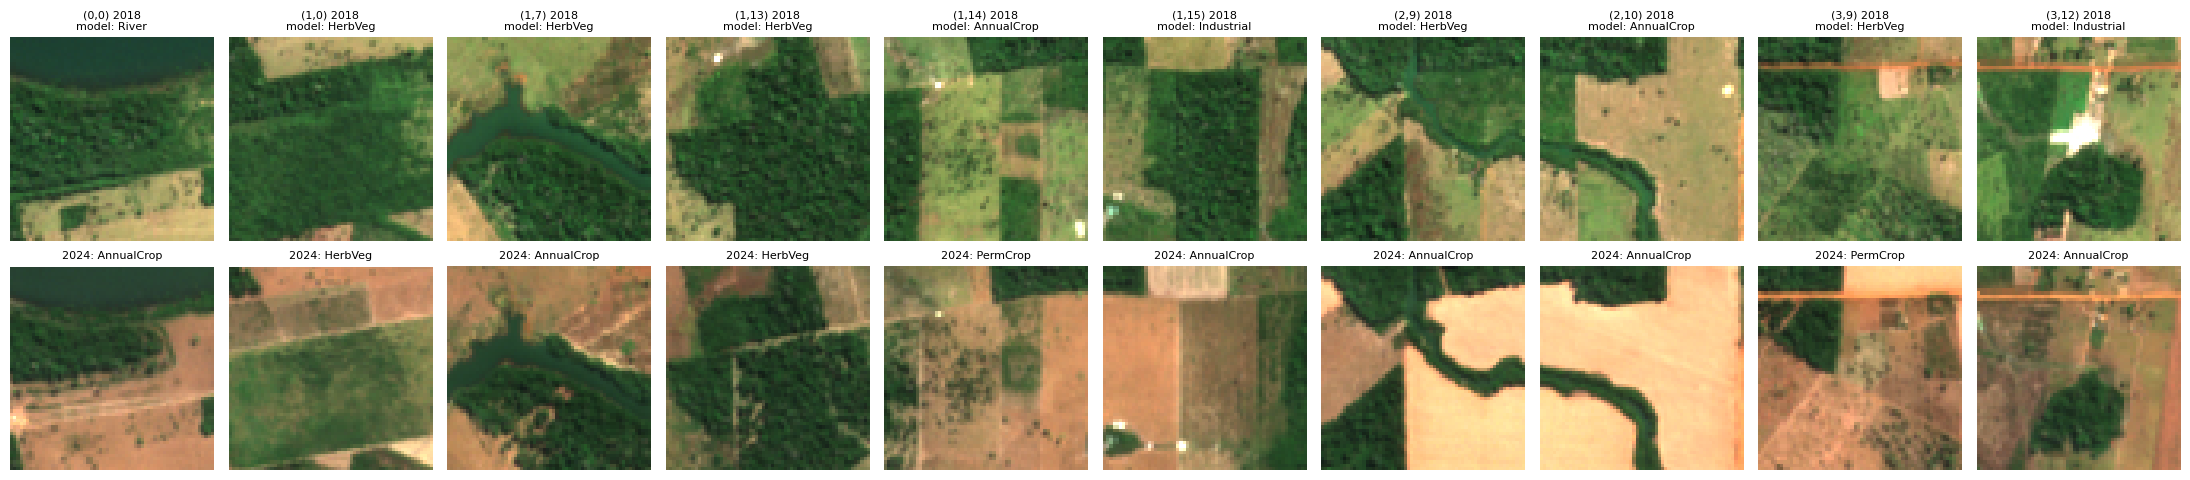

In [20]:
miss_r, miss_c = np.where(hansen & ~change)
print("missed patches:", len(miss_r))

n_show = 10
fig, ax = plt.subplots(2, n_show, figsize=(2.2*n_show, 5))
for i in range(n_show):
    r, c = miss_r[i], miss_c[i]
    ax[0, i].imshow(img18[r*64:(r+1)*64, c*64:(c+1)*64])
    ax[0, i].set_title(f"({r},{c}) 2018\nmodel: {classes[map18[r,c]]}", fontsize=8)
    ax[1, i].imshow(img24[r*64:(r+1)*64, c*64:(c+1)*64])
    ax[1, i].set_title(f"2024: {classes[map24[r,c]]}", fontsize=8)
    ax[0, i].axis("off"); ax[1, i].axis("off")
plt.tight_layout(); plt.show()

false alarms: 8


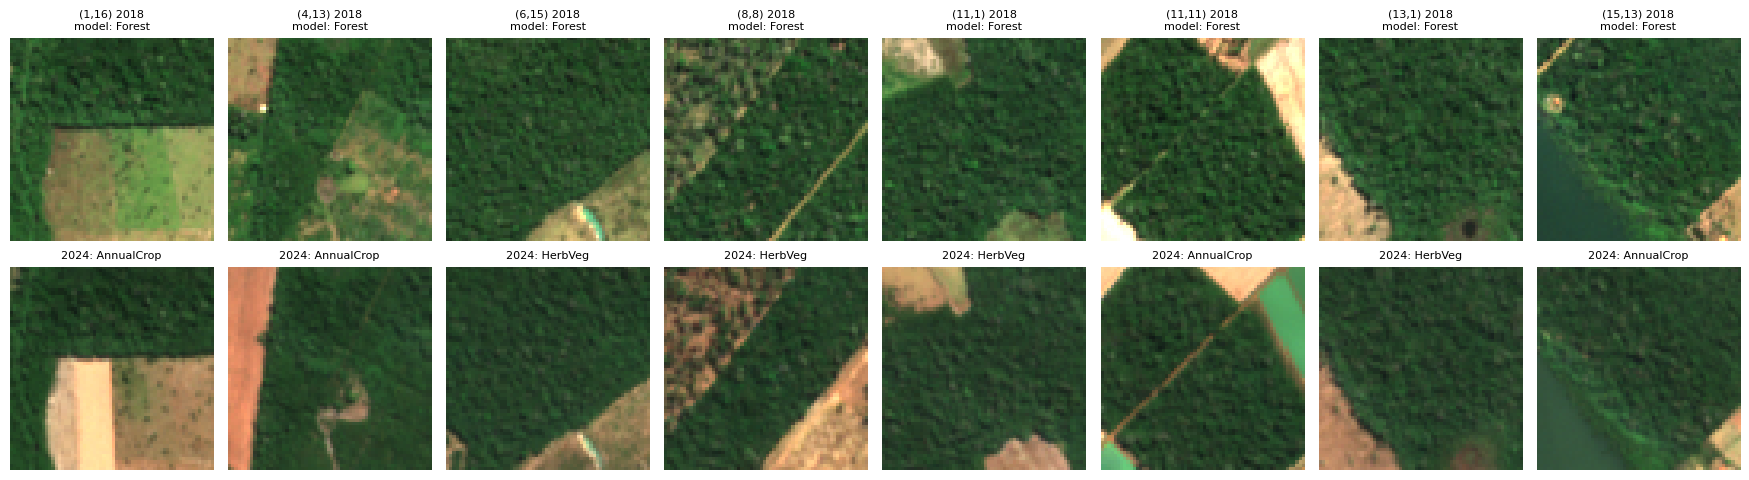

In [21]:
fa_r, fa_c = np.where(change & ~hansen)
print("false alarms:", len(fa_r))

n = len(fa_r)
fig, ax = plt.subplots(2, n, figsize=(2.2*n, 5))
for i in range(n):
    r, c = fa_r[i], fa_c[i]
    ax[0, i].imshow(img18[r*64:(r+1)*64, c*64:(c+1)*64])
    ax[0, i].set_title(f"({r},{c}) 2018\nmodel: {classes[map18[r,c]]}", fontsize=8)
    ax[1, i].imshow(img24[r*64:(r+1)*64, c*64:(c+1)*64])
    ax[1, i].set_title(f"2024: {classes[map24[r,c]]}", fontsize=8)
    ax[0, i].axis("off"); ax[1, i].axis("off")
plt.tight_layout(); plt.show()

# How to predict feature results with our model

In [ ]:
# ============================================================
#  HOW TO USE THIS MODEL TO PREDICT ON NEW SATELLITE IMAGES
# ============================================================
#
#  ------------- STEP 0: GET THE FILES YOU NEED -------------
#  You need ONE file to run predictions:
#      eurosat_resnet50.pt      (the trained model weights)
#  Optional, to reproduce our Amazon results, also grab:
#      amazon_2018.tif, amazon_2024.tif
#  All are in this GitHub repo — on the repo page, click the
#  file -> click "Download raw file" (top right of file view).
#
#  If the weights are NOT in the repo (file too big), you have
#  two options:
#    a) run the training cells in the notebook once (~40 min on
#       a free Colab GPU) — they end by saving this exact file, or
#    b) contact the repo owner via GitHub Issues.
#
#  ------- STEP 0.5: PUT THE FILES WHERE COLAB SEES THEM ------
#  You are (probably) running this in Google Colab. Colab can
#  read files from two places — pick ONE:
#
#  OPTION A — direct upload (simplest, but re-upload every session):
#    1. In Colab, click the FOLDER icon on the left sidebar
#    2. Click the UPLOAD icon (page with up-arrow)
#    3. Select eurosat_resnet50.pt (and any .tif files)
#    4. They land at /content/ — so set below:
#         WEIGHTS_PATH = "/content/eurosat_resnet50.pt"
#
#  OPTION B — via your own Google Drive (upload once, keep forever):
#    1. Go to drive.google.com -> New -> File upload
#       -> upload eurosat_resnet50.pt (and .tif files)
#       (put them in a folder, e.g. "research2", to stay tidy)
#    2. In Colab, run:
#         from google.colab import drive
#         drive.mount("/content/drive")
#       and click through the permission popup
#    3. Your file is now at:
#         WEIGHTS_PATH = "/content/drive/MyDrive/research2/eurosat_resnet50.pt"
#       (adjust to match YOUR folder name exactly — capital
#        letters and spaces matter!)
#
#  If you see "No such file or directory": the path doesn't
#  match where the file really is. Run this to list what Colab
#  actually sees, and copy the printed path:
#      import glob; print(glob.glob("/content/**/*.pt", recursive=True) +
#                         glob.glob("/content/**/*.tif", recursive=True))
#
#  ------- STEP 0.9: PREDICTING YOUR OWN REGION? -------
#  You need your own GeoTIFFs: RGB bands (B4,B3,B2), 10m/pixel,
#  same rectangle for both years, same season. The notebook's
#  Earth Engine export cell does exactly this — you need a free
#  Earth Engine account (earthengine.google.com, register a
#  noncommercial project), then change the `region` coordinates
#  and dates in that cell and run it. Exports land in YOUR Drive.
#
#  ------------------- HONEST WARNING -------------------
#  (from our own research results)
#  This model scored 93% on European benchmark data but only
#  detected 19% of real deforestation in the Amazon, because it
#  often fails to recognize tropical forest as Forest.
#  Predictions on NON-EUROPEAN imagery are unreliable.
#  Use on European-like landscapes, or fine-tune first.
# ============================================================

import torch, torchvision
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from PIL import Image
from torchvision import transforms

# ---------- STEP 1: SETUP (run once) ----------
# The 10 classes, in the model's fixed order. Forest = index 1.
CLASSES = ["AnnualCrop","Forest","HerbaceousVegetation","Highway",
           "Industrial","Pasture","PermanentCrop","Residential",
           "River","SeaLake"]

device = "cuda" if torch.cuda.is_available() else "cpu"

# The EXACT preprocessing used in training. Never change this —
# different preparation = the model sees alien pixels = garbage.
tf = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ---------- STEP 2: LOAD THE TRAINED MODEL ----------
# >>> EDIT THIS LINE to match where YOUR file is (see STEP 0.5):
WEIGHTS_PATH = "/content/eurosat_resnet50.pt"

model = torchvision.models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
model = model.to(device)
model.eval()          # prediction mode — no learning happens
print("model loaded on", device)

# ---------- (A) PREDICT ONE PATCH ----------
def predict_patch(img_array):
    """
    INPUT:  a numpy array of shape (64, 64, 3), values 0-255
            (any small RGB image works; 64x64 matches training)
    OUTPUT: (class_name, confidence)
    HOW TO USE:
        label, conf = predict_patch(my_patch)
        print(label, conf)          # e.g.  Forest 0.97
    """
    x = tf(Image.fromarray(img_array.astype(np.uint8)))
    x = x.unsqueeze(0).to(device)           # add batch dimension
    with torch.no_grad():                   # no gradients needed
        probs = F.softmax(model(x), 1)[0]
    top = probs.argmax().item()
    return CLASSES[top], round(probs[top].item(), 3)

# ---------- (B) PREDICT A WHOLE GEOTIFF -> LAND-COVER MAP ----------
def load_geotiff(path):
    """Loads an RGB GeoTIFF and prepares it as a 0-255 image array."""
    import rasterio
    with rasterio.open(path) as src:
        img = src.read([1, 2, 3])              # R, G, B bands
    img = np.transpose(img, (1, 2, 0))
    img = np.clip(img / np.quantile(img, 0.98), 0, 1)
    return (img * 255).astype(np.uint8)

def classify_image(path, tile=64):
    """
    INPUT:  path to a GeoTIFF
    OUTPUT: a 2D grid of class indices (the land-cover map)
    HOW TO USE:
        my_map = classify_image("region_2025.tif")
        import matplotlib.pyplot as plt
        plt.imshow(my_map, cmap="tab10", vmin=0, vmax=9); plt.show()
    """
    img = load_geotiff(path)
    h, w, _ = img.shape
    rows, cols = h // tile, w // tile
    labels = np.zeros((rows, cols), dtype=int)
    with torch.no_grad():
        for r in range(rows):
            for c in range(cols):
                patch = img[r*tile:(r+1)*tile, c*tile:(c+1)*tile]
                x = tf(Image.fromarray(patch)).unsqueeze(0).to(device)
                labels[r, c] = model(x).argmax(1).item()
    return labels

# ---------- (C) TWO YEARS -> DEFORESTATION MAP ----------
def detect_deforestation(path_before, path_after):
    """
    INPUT:  two GeoTIFFs of the SAME rectangle, different dates
            (same season recommended — avoids fake seasonal change)
    OUTPUT: True/False grid — True = was Forest, now isn't
    HOW TO USE:
        flags = detect_deforestation("area_2018.tif", "area_2024.tif")
        print("flagged patches:", flags.sum())
        print("flagged km2:", flags.sum() * 0.64 * 0.64)
    NOTE: the model never says "deforestation" itself — this
    function applies OUR rule on top of its two land-cover maps.
    """
    FOREST = 1
    map_before = classify_image(path_before)
    map_after  = classify_image(path_after)
    return (map_before == FOREST) & (map_after != FOREST)

# ---------- QUICK TEST ----------
# Uncomment to test on your own files (fix paths first):
# flags = detect_deforestation(
#     "/content/amazon_2018.tif",
#     "/content/amazon_2024.tif")
# print("flagged:", flags.sum())